# Resource-Constrained GA: Ablation Study

This notebook runs a GA optimization with total seasonal resource usage capped at MPC's maximum levels
(2.0 inches water, 310 lbs fertilizer). The goal is to disentangle whether MPC's lower revenue stems
from its short planning horizon or from implicit resource conservation in its quadratic cost formulation.

If the constrained GA still outperforms MPC, the horizon advantage is the dominant factor.
If it performs similarly to MPC, resource conservation explains the gap.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import sys
import time

here = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.abspath(os.path.join(here, '../../'))
sys.path.insert(0, project_root)

from core.ga.ga_bounds import DesignSpaceBounds
from core.ga.ga_params import GeneticAlgorithmParams
from core.ga.ga import GeneticAlgorithm
from core.ga.ga_member import Member
from core.ga.ga_population import Population

from core.model.model_carrying_capacities import ModelCarryingCapacities
from core.model.model_disturbances import ModelDisturbances
from core.model.model_growth_rates import ModelGrowthRates
from core.model.model_initial_conditions import ModelInitialConditions
from core.model.model_params import ModelParams
from core.model.model_typical_disturbances import ModelTypicalDisturbances
from core.model.model_sensitivities import ModelSensitivities

from core.plotting.plotting_params import PlottingParams
from core.plotting.plotting_colors import PlottingColors

plotting_params = PlottingParams()
plotting_colors = PlottingColors()
plotting_colors.apply_as_default()

## 1. Load Weather Scenarios

In [2]:
# Load weather scenarios generated by ga_weather_scenarios.ipynb
weather_dir = os.path.join(here, '../weather/weather_scenario_results')

with open(os.path.join(weather_dir, 'weather_scenarios.pkl'), 'rb') as f:
    weather_data = pickle.load(f)

print(f"Loaded {len(weather_data)} weather scenarios")

Loaded 21 weather scenarios


## 2. Model Parameters

In [3]:
model_params = ModelParams(
    dt               = 1.0,
    simulation_hours = 2900,
    verbose          = False
)

carrying_capacities = ModelCarryingCapacities(
    kh = 3.0, kA = 0.65, kN = 20, kc = 1000, kP = 0.25
)

growth_rates = ModelGrowthRates(
    ah = 0.01, aA = 0.0105, aN = 0.011, ac = 0.01, aP = 0.005
)

sensitivities = ModelSensitivities(
    sigma_W = 30, sigma_F = 300, sigma_T = 30, sigma_R = 30
)

initial_conditions = ModelInitialConditions(
    h0 = carrying_capacities.kh / model_params.simulation_hours,
    A0 = carrying_capacities.kA / model_params.simulation_hours,
    N0 = carrying_capacities.kN / model_params.simulation_hours,
    c0 = carrying_capacities.kc / model_params.simulation_hours,
    P0 = carrying_capacities.kP / model_params.simulation_hours
)

default_typical = ModelTypicalDisturbances()
typical_disturbances = ModelTypicalDisturbances(
    typical_water       = default_typical.typical_water * model_params.dt,
    typical_fertilizer  = default_typical.typical_fertilizer * model_params.dt,
    typical_temperature = default_typical.typical_temperature * model_params.dt,
    typical_radiation   = default_typical.typical_radiation * model_params.dt
)

## 3. Resource-Constrained GA Parameters

Cap total seasonal inputs at MPC's maximum usage across all 21 scenarios:
- Water: 2.0 inches (MPC max = 1.98)
- Fertilizer: 310 lbs (MPC max = 307)

In [4]:
# Resource caps matching MPC's maximum usage
MAX_SEASONAL_WATER = 2.0       # inches
MAX_SEASONAL_FERTILIZER = 310  # lbs

# Same bounds as unconstrained GA
lower_bounds = np.array([12, 0, 24, 0])
upper_bounds = np.array([2900, 10, 2900, 700])
bounds = DesignSpaceBounds(lower_bounds=lower_bounds, upper_bounds=upper_bounds)

# GA params with resource constraints
ga_params = GeneticAlgorithmParams(
    num_parents             = 16,
    num_kids                = 16,
    num_generations         = 100,
    num_members             = 128,
    max_seasonal_water      = MAX_SEASONAL_WATER,
    max_seasonal_fertilizer = MAX_SEASONAL_FERTILIZER,
)

print(f"Resource constraints:")
print(f"  Max seasonal water:      {MAX_SEASONAL_WATER} inches")
print(f"  Max seasonal fertilizer: {MAX_SEASONAL_FERTILIZER} lbs")

Resource constraints:
  Max seasonal water:      2.0 inches
  Max seasonal fertilizer: 310 lbs


## 4. Run Constrained GA Optimization on Baseline Weather

In [5]:
baseline_weather = weather_data['baseline']
baseline_disturbances = ModelDisturbances(
    precipitation = baseline_weather['Hourly Precipitation (in)'].to_numpy(),
    radiation     = baseline_weather['Hourly Radiation (W/m2)'].to_numpy(),
    temperature   = baseline_weather['Temperature (C)'].to_numpy()
)

ga = GeneticAlgorithm(
    bounds               = bounds,
    ga_params            = ga_params,
    model_params         = model_params,
    carrying_capacities  = carrying_capacities,
    growth_rates         = growth_rates,
    initial_conditions   = initial_conditions,
    disturbances         = baseline_disturbances,
    typical_disturbances = typical_disturbances,
    sensitivities        = sensitivities
)

print("Running resource-constrained GA optimization on baseline weather...")
t_start = time.time()
ga_result = ga.run_with_cpp()
t_end = time.time()
print(f"Completed in {t_end - t_start:.1f} seconds")

Running resource-constrained GA optimization on baseline weather...


Time taken to evaluate population with C++ evaluator: 0.39520907402038574 seconds


Time taken to calculate costs for g=0: 0.4000060558319092 seconds
Generation 2 of 100
Time taken to breed kids for g=1: 0.00012493133544921875 seconds
Time taken to fill random members for g=1: 0.0011429786682128906 seconds


Time taken to evaluate population with C++ evaluator: 0.3915977478027344 seconds


Time taken to calculate costs for g=1: 0.39569592475891113 seconds
Lowest cost in generation 1: -747.63
Time taken to sort population for g=1: 4.38690185546875e-05 seconds
Generation 3 of 100
Time taken to breed kids for g=2: 0.00011014938354492188 seconds
Time taken to fill random members for g=2: 0.0013380050659179688 seconds


...


Time taken to calculate costs for g=97: 0.406353235244751 seconds
Lowest cost in generation 97: -876.32
Time taken to sort population for g=97: 2.7894973754882812e-05 seconds
Generation 99 of 100
Time taken to breed kids for g=98: 0.000225067138671875 seconds
Time taken to fill random members for g=98: 0.0008752346038818359 seconds


Time taken to evaluate population with C++ evaluator: 0.39856886863708496 seconds


Time taken to calculate costs for g=98: 0.4027249813079834 seconds
Lowest cost in generation 98: -876.32
Time taken to sort population for g=98: 4.982948303222656e-05 seconds
Generation 100 of 100
Time taken to breed kids for g=99: 0.00010704994201660156 seconds
Time taken to fill random members for g=99: 0.0011227130889892578 seconds


Time taken to evaluate population with C++ evaluator: 0.4017212390899658 seconds


Time taken to calculate costs for g=99: 0.405872106552124 seconds
Lowest cost in generation 99: -876.32
Time taken to sort population for g=99: 4.7206878662109375e-05 seconds
Completed in 40.7 seconds


In [6]:
# Extract optimal constrained strategy
optimal_strategy = ga_result.final_population.values[0]
optimal_cost = ga_result.final_population.costs[0]

# Verify resource usage
from core.model.model_helpers import get_sim_inputs_from_hourly
hourly_irr = np.zeros(model_params.simulation_hours)
step_if = max(1, int(np.ceil(optimal_strategy[0])))
hourly_irr[::step_if] = optimal_strategy[1]
total_water = np.sum(hourly_irr)

hourly_fert = np.zeros(model_params.simulation_hours)
step_ff = max(1, int(np.ceil(optimal_strategy[2])))
hourly_fert[::step_ff] = optimal_strategy[3]
total_fert = np.sum(hourly_fert)

print(f"\nOptimal Constrained Strategy:")
print(f"  Irrigation frequency: {optimal_strategy[0]:.1f} hours (every {optimal_strategy[0]/24:.1f} days)")
print(f"  Irrigation amount:    {optimal_strategy[1]:.3f} inches")
print(f"  Fertilizer frequency: {optimal_strategy[2]:.1f} hours (every {optimal_strategy[2]/24:.1f} days)")
print(f"  Fertilizer amount:    {optimal_strategy[3]:.1f} lbs")
print(f"\nTotal seasonal water:      {total_water:.3f} inches (cap: {MAX_SEASONAL_WATER})")
print(f"Total seasonal fertilizer: {total_fert:.1f} lbs (cap: {MAX_SEASONAL_FERTILIZER})")
print(f"\nExpected revenue on baseline: ${-optimal_cost:.2f}")


Optimal Constrained Strategy:
  Irrigation frequency: 2907.2 hours (every 121.1 days)
  Irrigation amount:    0.761 inches
  Fertilizer frequency: 580.6 hours (every 24.2 days)
  Fertilizer amount:    56.5 lbs

Total seasonal water:      0.761 inches (cap: 2.0)
Total seasonal fertilizer: 282.7 lbs (cap: 310)

Expected revenue on baseline: $876.32


## 5. Evaluate Constrained Strategy on All Weather Scenarios

In [7]:
# Use unconstrained ga_params for evaluation (constraints were only for optimization)
eval_ga_params = GeneticAlgorithmParams()
eval_model_params = ModelParams(
    dt               = model_params.dt,
    simulation_hours = model_params.simulation_hours,
    verbose          = True
)

constrained_results = {}

print("Evaluating constrained strategy on all scenarios...\n")

for scenario_name, weather_df in weather_data.items():
    scenario_disturbances = ModelDisturbances(
        precipitation = weather_df['Hourly Precipitation (in)'].to_numpy(),
        radiation     = weather_df['Hourly Radiation (W/m2)'].to_numpy(),
        temperature   = weather_df['Temperature (C)'].to_numpy()
    )

    member = Member(
        ga_params            = eval_ga_params,
        carrying_capacities  = carrying_capacities,
        disturbances         = scenario_disturbances,
        growth_rates         = growth_rates,
        initial_conditions   = initial_conditions,
        model_params         = eval_model_params,
        typical_disturbances = typical_disturbances,
        sensitivities        = sensitivities,
        values               = optimal_strategy
    )

    cost = member.get_cost()
    revenue = -cost

    output = pd.read_csv('output_get_cost.csv')

    constrained_results[scenario_name] = {
        'revenue': revenue,
        'fruit_biomass': output['P'].iloc[-1],
        'height': output['h'].iloc[-1],
        'leaf_area': output['A'].iloc[-1],
        'total_irrigation': total_water,
        'total_fertilizer': total_fert,
        'precip_total': weather_df['Hourly Precipitation (in)'].sum(),
        'temp_mean': weather_df['Temperature (C)'].mean()
    }

    print(f"{scenario_name:25s}: Revenue=${revenue:7.2f}")

Evaluating constrained strategy on all scenarios...



normal 1                 : Revenue=$ 876.47


normal 2                 : Revenue=$ 883.86


normal 3                 : Revenue=$ 848.03


normal 4                 : Revenue=$ 869.85


...

heat stress              : Revenue=$ 787.33


multiple heatwaves       : Revenue=$ 818.93


extreme drought heat     : Revenue=$ 500.95


worst case               : Revenue=$ 435.95


baseline                 : Revenue=$ 876.81


## 6. Compare with MPC Results

In [8]:
# Load MPC results
mpc_df = pd.read_csv(os.path.join(weather_dir, 'mpc_scenario_results.csv'))

# Build comparison dataframe
constrained_df = pd.DataFrame(constrained_results).T
constrained_df.index.name = 'scenario'
constrained_df = constrained_df.reset_index()

# Normalize scenario names for joining (MPC uses underscores)
constrained_df['scenario_key'] = constrained_df['scenario'].str.replace(' ', '_')
mpc_df['scenario_key'] = mpc_df['scenario']

comparison = constrained_df.merge(
    mpc_df[['scenario_key', 'revenue', 'total_irrigation', 'total_fertilizer']],
    on='scenario_key',
    suffixes=('_constrained_ga', '_mpc')
)

comparison['constrained_ga_advantage'] = comparison['revenue_constrained_ga'] - comparison['revenue_mpc']
comparison['constrained_ga_wins'] = comparison['constrained_ga_advantage'] > 0

print("Constrained GA vs MPC Comparison")
print("=" * 80)
for _, row in comparison.iterrows():
    winner = 'GA' if row['constrained_ga_wins'] else 'MPC'
    print(f"{row['scenario']:25s}: GA=${row['revenue_constrained_ga']:7.2f}  "
          f"MPC=${row['revenue_mpc']:7.2f}  "
          f"Diff=${row['constrained_ga_advantage']:+7.2f}  [{winner}]")

n_wins = comparison['constrained_ga_wins'].sum()
n_total = len(comparison)
print(f"\nConstrained GA wins {n_wins} of {n_total} scenarios")
print(f"\nMean revenue - Constrained GA: ${comparison['revenue_constrained_ga'].mean():.2f}")
print(f"Mean revenue - MPC:             ${comparison['revenue_mpc'].mean():.2f}")
print(f"Mean advantage:                 ${comparison['constrained_ga_advantage'].mean():+.2f}")

Constrained GA vs MPC Comparison
normal 1                 : GA=$ 876.47  MPC=$ 849.88  Diff=$ +26.59  [GA]
normal 2                 : GA=$ 883.86  MPC=$ 877.40  Diff=$  +6.46  [GA]
normal 3                 : GA=$ 848.03  MPC=$ 815.46  Diff=$ +32.57  [GA]
normal 4                 : GA=$ 869.85  MPC=$ 885.51  Diff=$ -15.66  [MPC]
normal 5                 : GA=$ 814.05  MPC=$ 774.34  Diff=$ +39.71  [GA]
moderate dry             : GA=$ 786.66  MPC=$ 796.31  Diff=$  -9.65  [MPC]
moderate wet             : GA=$ 762.16  MPC=$ 715.77  Diff=$ +46.38  [GA]
moderate warm            : GA=$ 832.07  MPC=$ 845.88  Diff=$ -13.81  [MPC]
moderate cool            : GA=$ 776.78  MPC=$ 735.63  Diff=$ +41.15  [GA]
moderate variable        : GA=$ 875.41  MPC=$ 847.43  Diff=$ +27.98  [GA]
mild drought             : GA=$ 687.96  MPC=$ 717.36  Diff=$ -29.40  [MPC]
summer drought           : GA=$ 734.79  MPC=$ 746.29  Diff=$ -11.50  [MPC]
early drought            : GA=$ 697.04  MPC=$ 726.64  Diff=$ -29.60  [MPC]

In [9]:
# Also load unconstrained GA results for three-way comparison
ga_normal_df = pd.read_csv(os.path.join(weather_dir, 'ga_scenario_results.csv'))
ga_normal_df['scenario_key'] = ga_normal_df['scenario'].str.replace(' ', '_')

three_way = comparison.merge(
    ga_normal_df[['scenario_key', 'revenue']].rename(columns={'revenue': 'revenue_ga_normal'}),
    on='scenario_key'
)

print("Three-Way Comparison: GA (Normal) vs Constrained GA vs MPC")
print("=" * 90)
print(f"{'Scenario':25s} {'GA(Normal)':>12s} {'GA(Constr)':>12s} {'MPC':>12s}")
print("-" * 90)
for _, row in three_way.iterrows():
    print(f"{row['scenario']:25s} ${row['revenue_ga_normal']:9.2f}  ${row['revenue_constrained_ga']:9.2f}  ${row['revenue_mpc']:9.2f}")

print(f"\n{'Mean':25s} ${three_way['revenue_ga_normal'].mean():9.2f}  "
      f"${three_way['revenue_constrained_ga'].mean():9.2f}  "
      f"${three_way['revenue_mpc'].mean():9.2f}")
print(f"{'Std':25s} ${three_way['revenue_ga_normal'].std():9.2f}  "
      f"${three_way['revenue_constrained_ga'].std():9.2f}  "
      f"${three_way['revenue_mpc'].std():9.2f}")

Three-Way Comparison: GA (Normal) vs Constrained GA vs MPC
Scenario                    GA(Normal)   GA(Constr)          MPC
------------------------------------------------------------------------------------------
normal 1                  $  1010.44  $   876.47  $   849.88
normal 2                  $  1014.63  $   883.86  $   877.40
normal 3                  $   977.53  $   848.03  $   815.46
normal 4                  $   992.19  $   869.85  $   885.51
normal 5                  $   935.24  $   814.05  $   774.34
moderate dry              $   890.76  $   786.66  $   796.31
moderate wet              $   873.54  $   762.16  $   715.77
moderate warm             $   944.68  $   832.07  $   845.88
moderate cool             $   887.02  $   776.78  $   735.63
moderate variable         $  1009.19  $   875.41  $   847.43
mild drought              $   774.25  $   687.96  $   717.36
summer drought            $   828.27  $   734.79  $   746.29
early drought             $   783.22  $   697.04  $  

## 7. Visualization

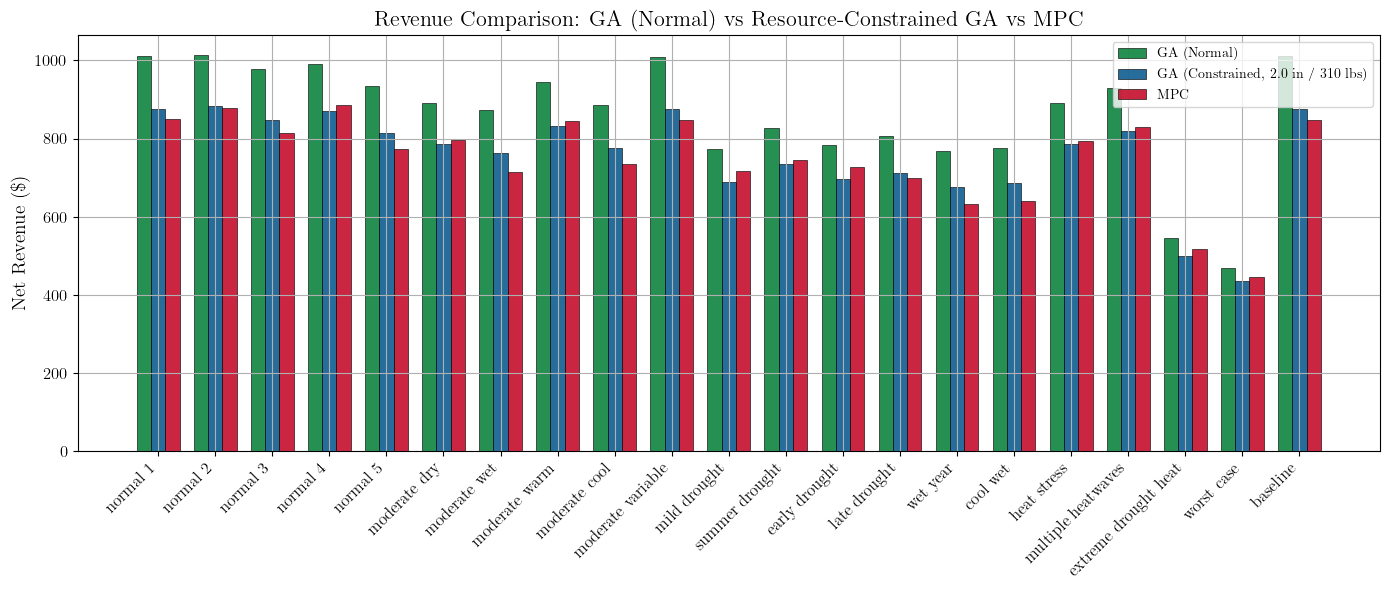

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(three_way))
width = 0.25

bars1 = ax.bar(x - width, three_way['revenue_ga_normal'], width,
               label='GA (Normal)', color=plotting_colors.vivid_green, alpha=0.85,
               edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, three_way['revenue_constrained_ga'], width,
               label=f'GA (Constrained, {MAX_SEASONAL_WATER} in / {MAX_SEASONAL_FERTILIZER} lbs)',
               color=plotting_colors.strong_blue, alpha=0.85,
               edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, three_way['revenue_mpc'], width,
               label='MPC', color=plotting_colors.vivid_red, alpha=0.85,
               edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(three_way['scenario'], rotation=45, ha='right')
ax.set_ylabel('Net Revenue (\\$)')
ax.set_title('Revenue Comparison: GA (Normal) vs Resource-Constrained GA vs MPC')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('ga_resource_constrained_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results

In [11]:
# Save constrained GA results
constrained_df.to_csv('constrained_ga_scenario_results.csv', index=False)

with open('constrained_ga_optimal_strategy.pkl', 'wb') as f:
    pickle.dump({
        'strategy': optimal_strategy,
        'baseline_cost': optimal_cost,
        'baseline_revenue': -optimal_cost,
        'max_seasonal_water': MAX_SEASONAL_WATER,
        'max_seasonal_fertilizer': MAX_SEASONAL_FERTILIZER
    }, f)

three_way.to_csv('constrained_ga_three_way_comparison.csv', index=False)

print("Results saved.")

Results saved.
